In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    brier_score_loss,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split


In [10]:
# 1. Simulación de cohorte clínica sintética (N = 6,000 pacientes)
np.random.seed(42)
n_samples = 6000

edad = np.random.normal(62, 12, n_samples).clip(18, 95).round()
presion_arterial_media = np.random.normal(75, 14, n_samples)
lactato = np.random.exponential(1.8, n_samples)
creatinina = np.random.lognormal(0.2, 0.4, n_samples)

# Probabilidad latente no lineal de fallo hemodinámico
log_odds = (
    -4.5 
    + 0.03 * edad 
    - 0.04 * presion_arterial_media 
    + 0.65 * lactato 
    + 0.50 * creatinina
)
prob_real = 1 / (1 + np.exp(-log_odds))
evento_adverso = np.random.binomial(1, prob_real)

df_salud = pd.DataFrame({
    'edad': edad,
    'pam': presion_arterial_media,
    'lactato': lactato,
    'creatinina': creatinina,
    'evento': evento_adverso
})

df_salud.head()

,edad,pam,lactato,creatinina,evento
0,68.0,59.402861,0.848297,0.874261,0
1,60.0,66.166968,1.551492,0.641422,0
2,70.0,61.811157,1.039367,1.054580,0
3,80.0,67.328059,0.031497,1.913986,0
4,59.0,72.001896,9.208113,1.587855,1


In [ ]:
X = df_salud.drop(columns='evento')
y = df_salud['evento']

# 2. Partición de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

In [20]:
from sklearn.model_selection import RandomizedSearchCV

# 3. Entrenamiento del clasificador base
modelo_base = HistGradientBoostingClassifier(
    random_state=42,
    class_weight='balanced',
    )

randon_search = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions={
        'learning_rate': [0.01, 0.05, 0.1],
        'max_iter': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'min_samples_leaf': [20, 50, 100]
    },
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

randon_search.fit(X_train, y_train)

# Mètricas de desempeño del modelo base

print("Prevalencia real de eventos:", y_test.mean())

probs_raw = randon_search.best_estimator_.predict_proba(X_test)[:, 1]
print("AUC-ROC del modelo base:", roc_auc_score(y_test, probs_raw))
print("Brier Score del modelo base:", brier_score_loss(y_test, probs_raw))

Prevalencia real de eventos: 0.051666666666666666
AUC-ROC del modelo base: 0.8604512727478881
Brier Score del modelo base: 0.11835396240379466


In [21]:
classification_report_base = classification_report(y_test, randon_search.best_estimator_.predict(X_test), output_dict=True)
print("=== REPORTE DE CLASIFICACIÓN (MODELO BASE) ===")
print(pd.DataFrame(classification_report_base).transpose())

=== REPORTE DE CLASIFICACIÓN (MODELO BASE) ===
              precision    recall  f1-score      support
0              0.981321  0.861746  0.917654  1707.000000
1              0.215947  0.698925  0.329949    93.000000
accuracy       0.853333  0.853333  0.853333     0.853333
macro avg      0.598634  0.780335  0.623802  1800.000000
weighted avg   0.941777  0.853333  0.887290  1800.000000


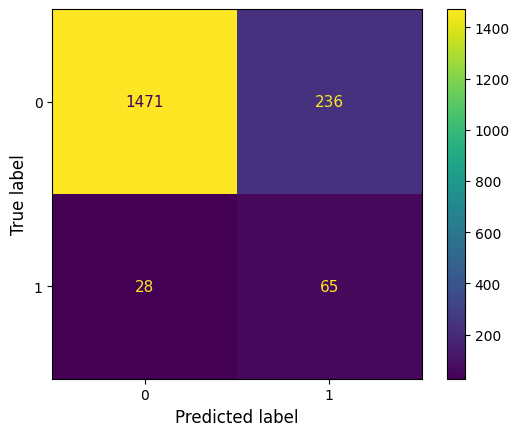

In [22]:
ConfusionMatrixDisplay.from_estimator(randon_search.best_estimator_, X_test, y_test)

In [23]:
# 4. Calibración sigmoidea (Platt Scaling)
# Enfoque con validación interna para no sesgar probabilidades
modelo_calibrado = CalibratedClassifierCV(estimator=randon_search.best_estimator_, cv=5, method='sigmoid')
modelo_calibrado.fit(X_train, y_train)


probs_cal = modelo_calibrado.predict_proba(X_test)[:, 1]

# 5. Evaluación: Discriminación vs. Calibración

print("=== EVALUACIÓN EN SALUD ===")
print(f"Prevalencia real de eventos: {y_test.mean():.2%}")
print(f"ROC-AUC (Base):       {roc_auc_score(y_test, probs_raw):.4f}")
print(f"ROC-AUC (Calibrado):  {roc_auc_score(y_test, probs_cal):.4f}")
print(f"Brier Score (Base):      {brier_score_loss(y_test, probs_raw):.4f}  (menor es mejor)")
print(f"Brier Score (Calibrado): {brier_score_loss(y_test, probs_cal):.4f}  (menor es mejor)")

=== EVALUACIÓN EN SALUD ===
Prevalencia real de eventos: 5.17%
ROC-AUC (Base):       0.8605
ROC-AUC (Calibrado):  0.8633
Brier Score (Base):      0.1184  (menor es mejor)
Brier Score (Calibrado): 0.0385  (menor es mejor)


In [24]:
classification_report_calibrado = classification_report(y_test, modelo_calibrado.predict(X_test), output_dict=True)
print("=== REPORTE DE CLASIFICACIÓN (MODELO CALIBRADO) ===")
print(pd.DataFrame(classification_report_calibrado).transpose())

=== REPORTE DE CLASIFICACIÓN (MODELO CALIBRADO) ===
              precision    recall  f1-score      support
0              0.960272  0.991213  0.975497  1707.000000
1              0.605263  0.247312  0.351145    93.000000
accuracy       0.952778  0.952778  0.952778     0.952778
macro avg      0.782768  0.619262  0.663321  1800.000000
weighted avg   0.941930  0.952778  0.943239  1800.000000


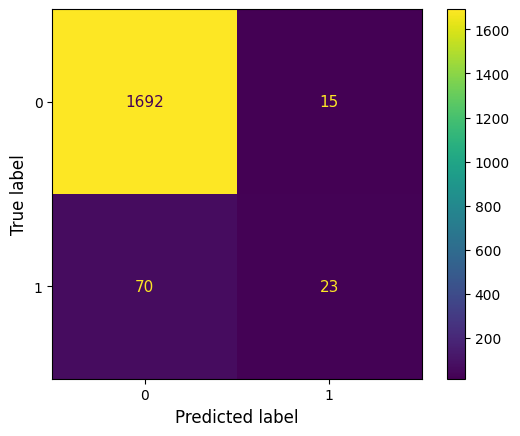

In [25]:
ConfusionMatrixDisplay.from_estimator(modelo_calibrado, X_test, y_test)

In [ ]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_s, y_s, test_size=0.30, stratify=y_s, random_state=42
)

base_s = HistGradientBoostingClassifier(random_state=42)
base_s.fit(X_train_s, y_train_s)

calibrado_s = CalibratedClassifierCV(estimator=base_s, cv=5, method='sigmoid')
calibrado_s.fit(X_train_s, y_train_s)

probs_raw_s = base_s.predict_proba(X_test_s)[:, 1]
probs_cal_s = calibrado_s.predict_proba(X_test_s)[:, 1]

# Cálculo de curvas de calibración (10 cuantiles/bins)
frac_pos_raw, mean_pred_raw = calibration_curve(y_test_s, probs_raw_s, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test_s, probs_cal_s, n_bins=10)

brier_raw = brier_score_loss(y_test_s, probs_raw_s)
brier_cal = brier_score_loss(y_test_s, probs_cal_s)

In [ ]:
# ==========================================
# 2. EJECUCIÓN DEL MODELO DE POLÍTICAS PÚBLICAS
# ==========================================
np.random.seed(101)
n_social = 8000

grupo_mayor_45 = np.random.binomial(1, 0.40, n_social)
meses_desempleo = np.random.poisson(8, n_social) + 3 * grupo_mayor_45
anios_escolaridad = np.random.normal(11, 2.5, n_social).clip(3, 18)
ingresos_previos = np.random.exponential(1.5, n_social)

score_social = -1.5 + 0.15 * meses_desempleo - 0.18 * anios_escolaridad - 0.35 * ingresos_previos + 0.40 * grupo_mayor_45
prob_social = 1 / (1 + np.exp(-score_social))
target_social = np.random.binomial(1, prob_social)

df_soc = pd.DataFrame({
    'meses_desempleo': meses_desempleo,
    'anios_escolaridad': anios_escolaridad,
    'ingresos_previos': ingresos_previos,
    'target': target_social
})

train_soc, test_soc = train_test_split(df_soc, test_size=0.25, stratify=df_soc['target'], random_state=101)
features_soc = ['meses_desempleo', 'anios_escolaridad', 'ingresos_previos']

modelo_soc = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=101)
modelo_soc.fit(train_soc[features_soc], train_soc['target'])

probs_soc = modelo_soc.predict_proba(test_soc[features_soc])[:, 1]
eval_soc = test_soc[['target']].copy()
eval_soc['score'] = probs_soc
eval_soc = eval_soc.sort_values(by='score', ascending=False).reset_index(drop=True)

# Cálculo acumulado de Precision@k
k_range = np.arange(1, len(eval_soc) + 1)
cum_positives = eval_soc['target'].cumsum()
precision_at_k = cum_positives / k_range
tasa_base = eval_soc['target'].mean()

# ==========================================
# 3. CONSTRUCCIÓN DE LAS FIGURAS
# ==========================================

# Configuración estética general
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Curva de Calibración (Salud)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibración perfecta (y = x)')
axes[0].plot(mean_pred_raw, frac_pos_raw, marker='s', linewidth=1.8, color='#d95f02', 
             label=f'Sin calibrar (Brier: {brier_raw:.4f})')
axes[0].plot(mean_pred_cal, frac_pos_cal, marker='o', linewidth=1.8, color='#1b9e77', 
             label=f'Calibrado Sigmoid (Brier: {brier_cal:.4f})')

axes[0].set_title('Salud: Diagrama de Confiabilidad (Calibración)', fontweight='bold')
axes[0].set_xlabel('Probabilidad Predicha Media')
axes[0].set_ylabel('Fracción Observada de Eventos Positivos')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.0])
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', frameon=True)

# Panel 2: Curva Precision@k (Políticas Públicas)
axes[1].plot(k_range, precision_at_k, color='#2c7bb6', linewidth=2.0, label='Modelo (Random Forest)')
axes[1].axhline(y=tasa_base, color='#ca0020', linestyle='--', linewidth=1.5, 
                label=f'Asignación Aleatoria ({tasa_base:.1%})')

# Marcador del presupuesto operativo (k = 300)
k_destacado = 300
prec_k_val = precision_at_k[k_destacado - 1]
axes[1].axvline(x=k_destacado, color='black', linestyle=':', alpha=0.7)
axes[1].scatter([k_destacado], [prec_k_val], color='#2c7bb6', s=70, zorder=5)
axes[1].annotate(
    f'k = {k_destacado}\nPrecision: {prec_k_val:.1%}',
    xy=(k_destacado, prec_k_val),
    xytext=(k_destacado + 150, prec_k_val - 0.08),
    arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
    fontweight='bold'
)

axes[1].set_title('Políticas Públicas: Curva Precision@k', fontweight='bold')
axes[1].set_xlabel('Número de Individuos Seleccionados (k)')
axes[1].set_ylabel('Precisión Acumulada')
axes[1].set_xlim([0, len(eval_soc)])
axes[1].set_ylim([0.0, 1.05])
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()